----------Data Preprocess--------------

In [48]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [49]:
df = pd.read_csv('retail_large_dataset.csv')

In [50]:
df.head(10)

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No
5,C10005,31,Male,Delhi,Delhi,Regular,O50005,2025-02-15,Electronics,Smartphone,24397,1,1,24153.03,Cash on Delivery,Standard,4,No
6,C10006,24,Female,Ahmedabad,Gujarat,Regular,O50006,2023-02-04,Grocery,Pulses,15041,1,3,14589.77,Credit Card,Express,2,No
7,C10007,19,Male,Kolkata,West Bengal,Regular,O50007,2024-07-19,Electronics,Headphones,13917,4,21,43977.72,UPI,Standard,2,No
8,C10008,51,Male,Noida,Uttar Pradesh,New,O50008,2025-09-22,Health,Vitamins,33106,4,14,113884.64,UPI,Standard,8,No
9,C10009,57,Male,Chennai,Tamil Nadu,New,O50009,2024-12-20,Beauty,Shampoo,24800,2,14,42656.00,Cash on Delivery,Express,5,No


In [51]:
df.shape

(100000, 18)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   customer_id          100000 non-null  object 
 1   age                  100000 non-null  int64  
 2   gender               100000 non-null  object 
 3   city                 100000 non-null  object 
 4   state                100000 non-null  object 
 5   customer_segment     100000 non-null  object 
 6   order_id             100000 non-null  object 
 7   order_date           100000 non-null  object 
 8   product_category     100000 non-null  object 
 9   product_subcategory  100000 non-null  object 
 10  product_price        100000 non-null  int64  
 11  quantity             100000 non-null  int64  
 12  discount_percentage  100000 non-null  int64  
 13  final_price          100000 non-null  float64
 14  payment_method       100000 non-null  object 
 15  shipping_type     

In [53]:
df['order_date'] = pd.to_datetime(df['order_date'])

cat_cols = ['gender', 'customer_segment', 'product_category', 
            'payment_method', 'product_subcategory', 
            'return_status', 'shipping_type']

for col in cat_cols:
    df[col] = df[col].astype('category')

In [54]:
df.dtypes

customer_id                    object
age                             int64
gender                       category
city                           object
state                          object
customer_segment             category
order_id                       object
order_date             datetime64[ns]
product_category             category
product_subcategory          category
product_price                   int64
quantity                        int64
discount_percentage             int64
final_price                   float64
payment_method               category
shipping_type                category
delivery_days                   int64
return_status                category
dtype: object

In [55]:
print(f"Missing Values:\n{df.isnull().sum()}")
print(f"Total Duplicates: {df.duplicated().sum()}")

Missing Values:
customer_id            0
age                    0
gender                 0
city                   0
state                  0
customer_segment       0
order_id               0
order_date             0
product_category       0
product_subcategory    0
product_price          0
quantity               0
discount_percentage    0
final_price            0
payment_method         0
shipping_type          0
delivery_days          0
return_status          0
dtype: int64
Total Duplicates: 0


In [56]:
df.columns = df.columns.str.strip()

In [57]:
df.columns

Index(['customer_id', 'age', 'gender', 'city', 'state', 'customer_segment',
       'order_id', 'order_date', 'product_category', 'product_subcategory',
       'product_price', 'quantity', 'discount_percentage', 'final_price',
       'payment_method', 'shipping_type', 'delivery_days', 'return_status'],
      dtype='object')

In [58]:
df.head(3)

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No


----------Univariate Analysis------------

In [59]:
df.describe()

,age,order_date,product_price,quantity,discount_percentage,final_price,delivery_days
count,100000.000000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.561830,2024-06-29 02:48:38.304000,30164.526720,2.501790,15.009890,64165.723382,5.505540
min,18.000000,2023-01-01 00:00:00,500.000000,1.000000,0.000000,357.000000,1.000000
25%,30.000000,2023-09-30 00:00:00,15375.000000,1.000000,7.000000,24705.000000,3.000000
50%,42.000000,2024-06-28 00:00:00,30148.000000,3.000000,15.000000,49752.390000,5.000000
75%,54.000000,2025-03-30 00:00:00,44957.000000,4.000000,23.000000,94046.070000,8.000000
max,65.000000,2025-12-30 00:00:00,59998.000000,4.000000,30.000000,239980.000000,10.000000
std,13.852439,NaN,17139.679807,1.120058,8.953296,49969.280150,2.872868


In [60]:
num_cols = ['age', 'product_price', 'quantity', 'discount_percentage', 'final_price', 'delivery_days']

skewness = df[num_cols].skew()
kurtosis = df[num_cols].kurt()

# Combine results into a formatted DataFrame
distribution_analysis = pd.DataFrame({
    'Skewness': skewness,
    'Kurtosis': kurtosis
})

print("\n--- Distribution Shape Analysis ---")
print(distribution_analysis)


--- Distribution Shape Analysis ---
                     Skewness  Kurtosis
age                 -0.004988 -1.201172
product_price        0.003249 -1.195106
quantity            -0.003067 -1.364612
discount_percentage -0.003597 -1.201628
final_price          0.934747  0.169047
delivery_days        0.002270 -1.221514


Insights:

Most of your business metrics (Age, Quantity, Delivery Days) are incredibly balanced and stable, showing no extreme outliers.

The Final Price is the most "interesting" variable. Because it is right-skewed, your business likely relies on a "Long Tail" model where most orders are small, but the total profit is heavily influenced by high-value transactions.

The negative kurtosis across most columns suggests that the dataset is clean or extreme errors that usually cause high positive kurtosis.

In [61]:
import warnings
warnings.filterwarnings('ignore')


Frequency Distribution for product_category:
product_category
Health            16858
Home & Kitchen    16848
Fashion           16613
Grocery           16592
Electronics       16576
Beauty            16513
Name: count, dtype: int64


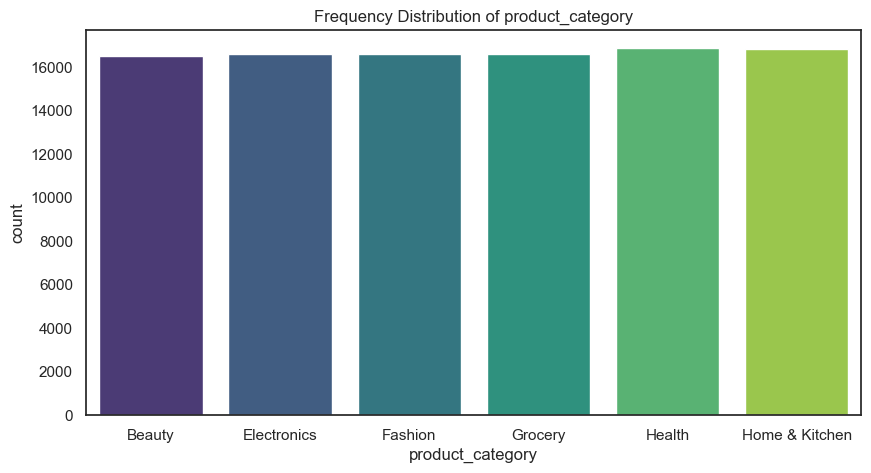


Frequency Distribution for customer_segment:
customer_segment
New        33488
Regular    33361
Premium    33151
Name: count, dtype: int64


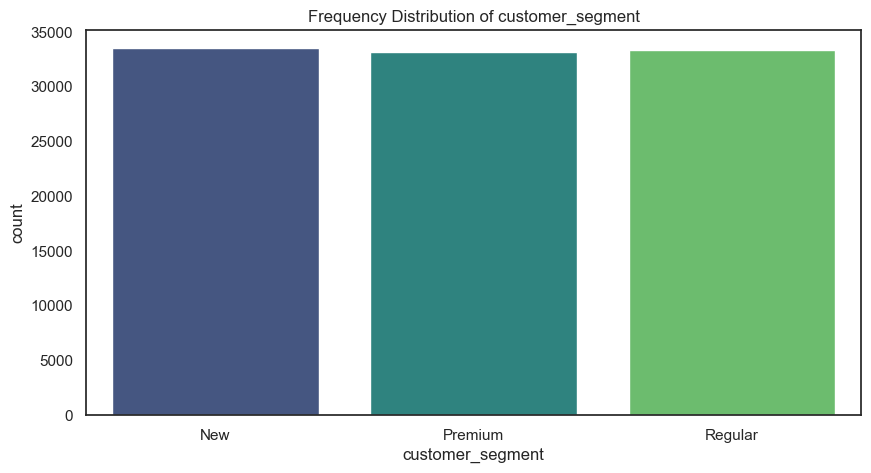


Frequency Distribution for payment_method:
payment_method
Credit Card         25307
UPI                 25139
Cash on Delivery    24994
Debit Card          24560
Name: count, dtype: int64


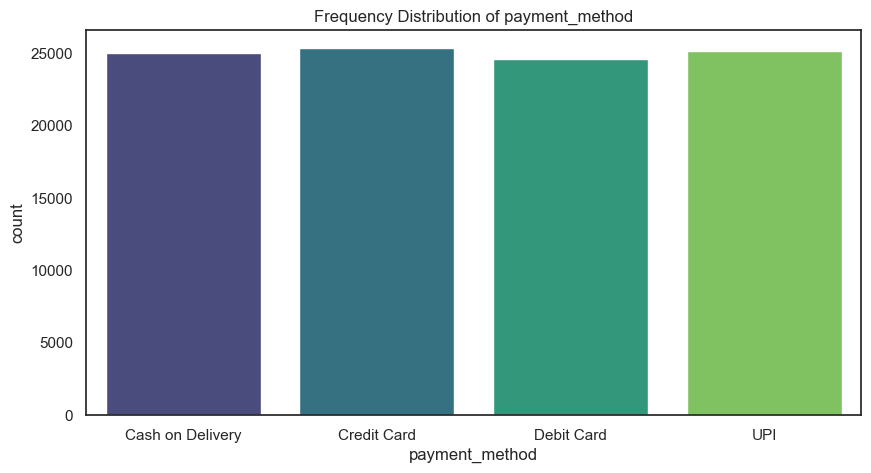


Frequency Distribution for return_status:
return_status
No     85189
Yes    14811
Name: count, dtype: int64


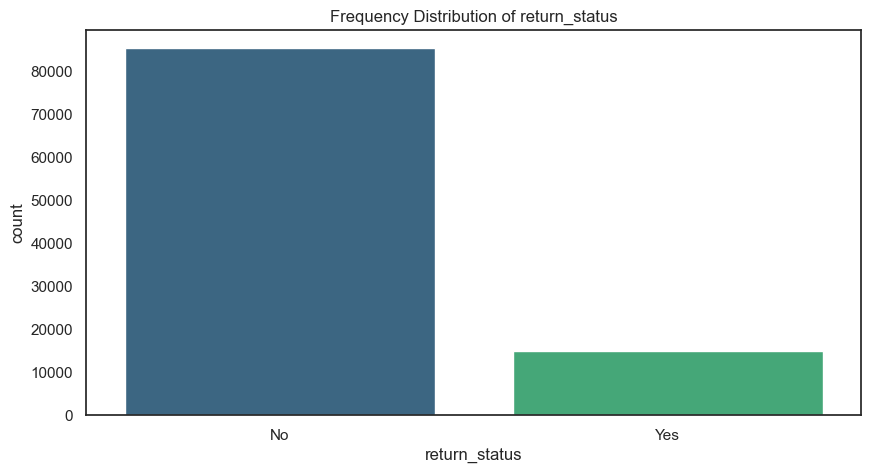

In [62]:
categorical_vars = ['product_category', 'customer_segment', 'payment_method', 'return_status']

for var in categorical_vars:

    print(f"\nFrequency Distribution for {var}:")
    print(df[var].value_counts())
    
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=var, palette='viridis')
    plt.title(f'Frequency Distribution of {var}')
    plt.show() 

Insights:

Above charts shown Frequency of all Categorical Values.

Low Risk: No over-reliance on a single product or payment type.

Strong Loyalty: Your "Premium" base is as large as your "New" base.

Trust: 85% of customers are satisfied with their purchases (No Return).

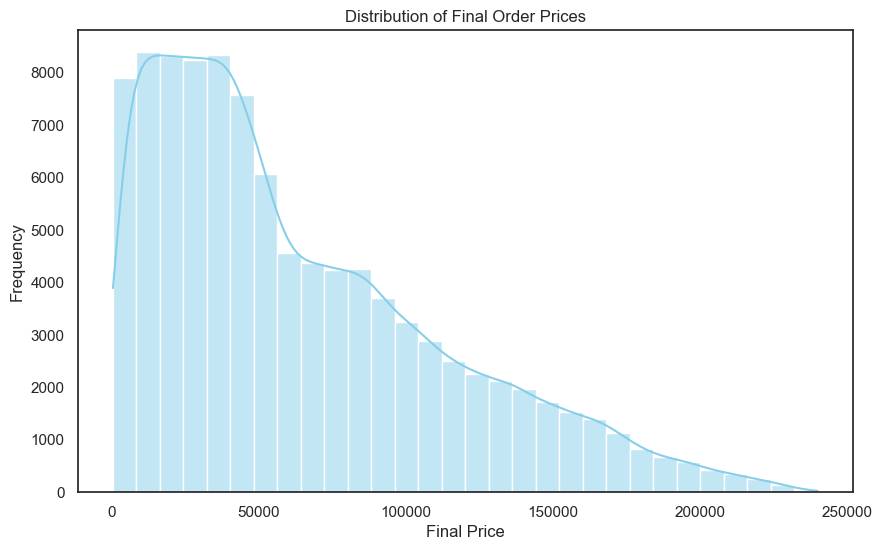

In [63]:
plt.figure(figsize=(10, 6))
sns.histplot(df['final_price'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Final Order Prices')
plt.xlabel('Final Price')
plt.ylabel('Frequency')
plt.show()

Insights:

Above chart shown Frequency of Final Price

The frequency peaks and stays consistently high (above 7,500 orders) until the 50,000 mark.

While these high-value orders (above 150000) are rare, they represent a "Premium" segment.

The gradual decline (rather than a total stop) after 100000 shows that your brand can support high-ticket items. There is an opportunity to convert more of your "mid-tier" customers (50000–100000) into "high-tier" customers (150000) through targeted upselling.

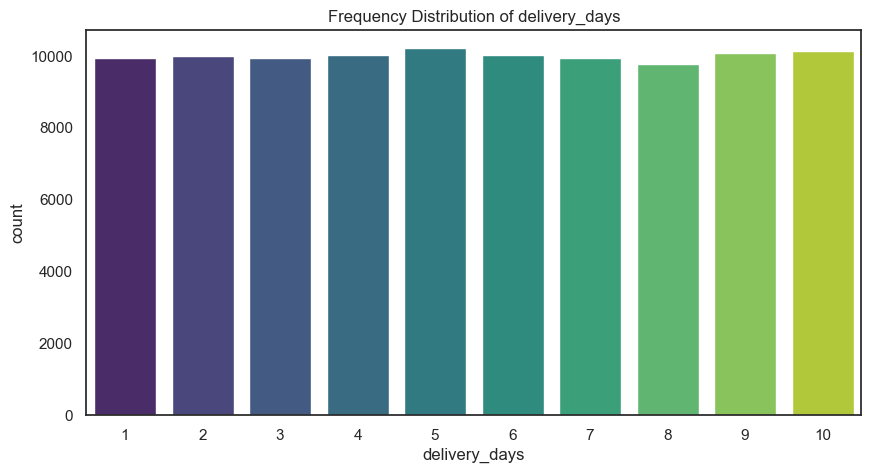

In [64]:
vars = ['delivery_days']

for var in vars:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=var, palette='viridis')
    plt.title(f'Frequency Distribution of {var}')
    plt.show() 

Insights:

Above chart shows count of delivery days.

As shown the chart delivery days are within 1 to 10 days.

The count for delivery_days is exactly 10,000 and each bar hits the 10,000 mark consistently.

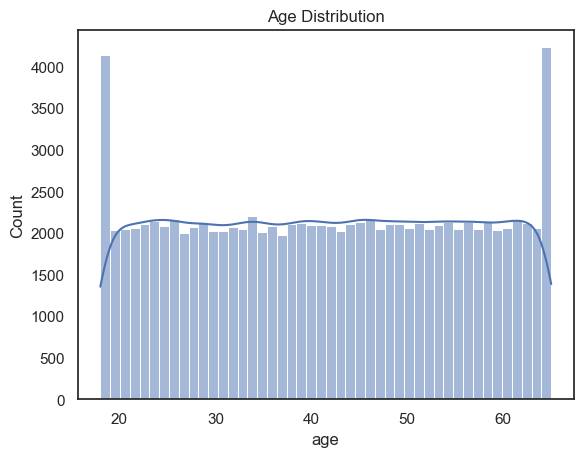

In [65]:
sns.histplot(df['age'], kde=True)
plt.title('Age Distribution')
plt.show()

Insights:

The Age Distribution histogram shows a remarkably uniform spread across the 20 to 65 age range, with two very distinct spikes at the boundaries.

Your business successfully attracts customers of almost every age group equally, from young adults (20s) to seniors (60s).

There is a massive spike at the age 20 mark, with counts reaching over 4,000—nearly double the average of other ages. This represents a huge entry-level user base with high long-term lifetime value.

A similar spike occurs at age 65.

---------------Outlier Detection-----------------

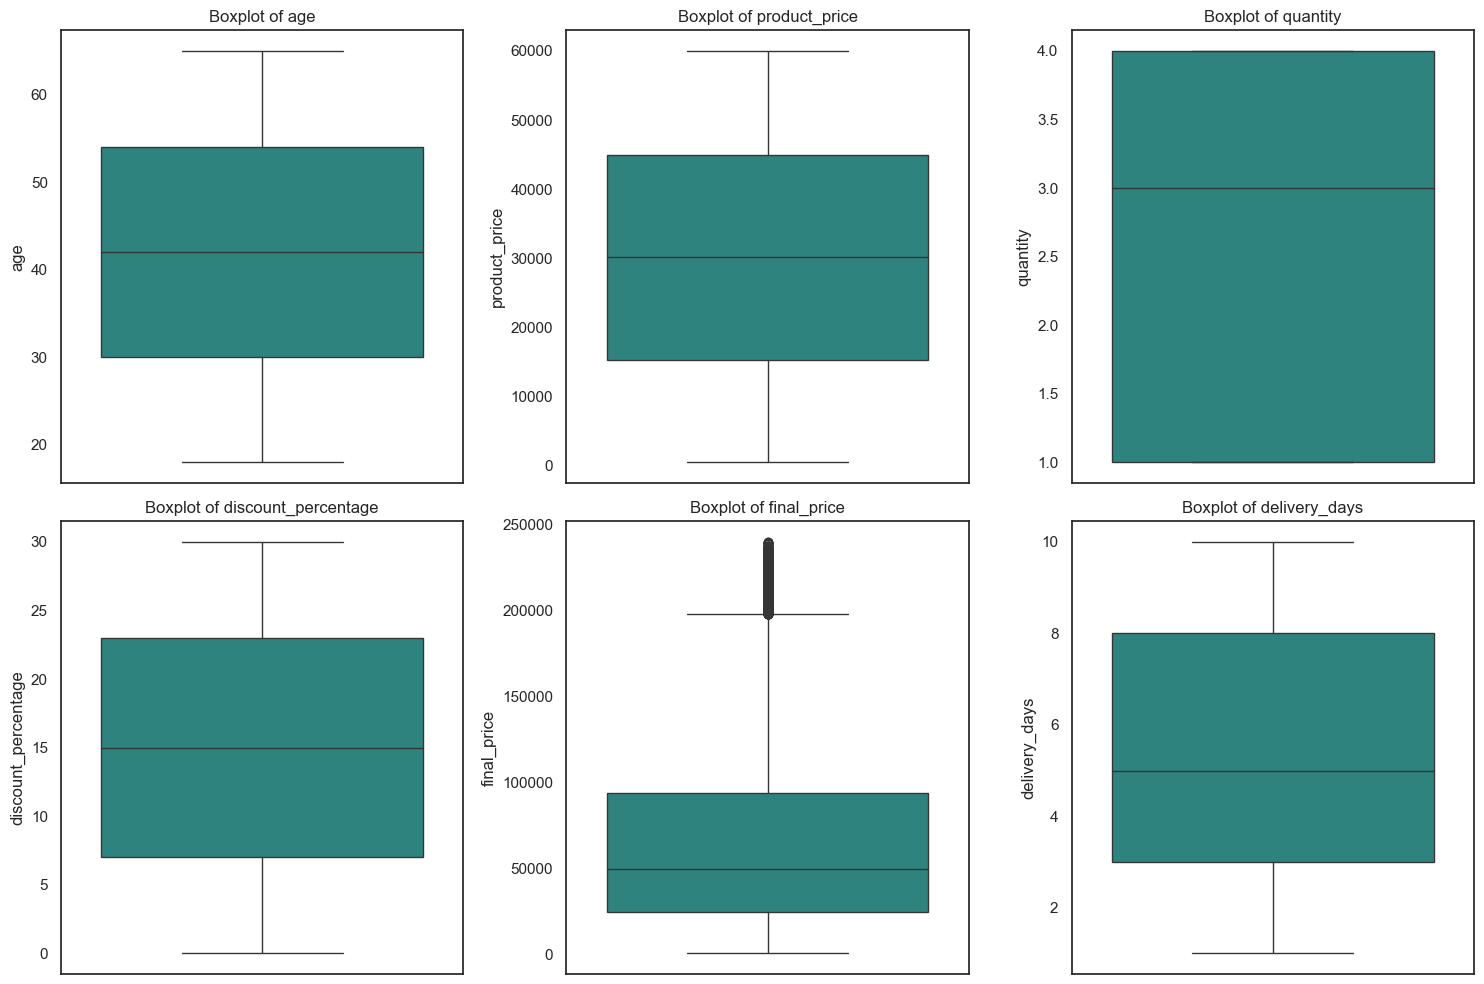

In [66]:
num_cols = ['age', 'product_price', 'quantity', 'discount_percentage', 'final_price', 'delivery_days']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[col], palette='viridis')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [67]:
print("--- IQR Method Outliers ---")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers detected")

--- IQR Method Outliers ---
age: 0 outliers detected
product_price: 0 outliers detected
quantity: 0 outliers detected
discount_percentage: 0 outliers detected
final_price: 1335 outliers detected
delivery_days: 0 outliers detected


In [68]:
from scipy import stats
for col in num_cols:
    z_scores = stats.zscore(df[col])
    outliers = df[np.abs(z_scores) > 3]
    print(f"{col}: {len(outliers)} outliers detected")

age: 0 outliers detected
product_price: 0 outliers detected
quantity: 0 outliers detected
discount_percentage: 0 outliers detected
final_price: 503 outliers detected
delivery_days: 0 outliers detected


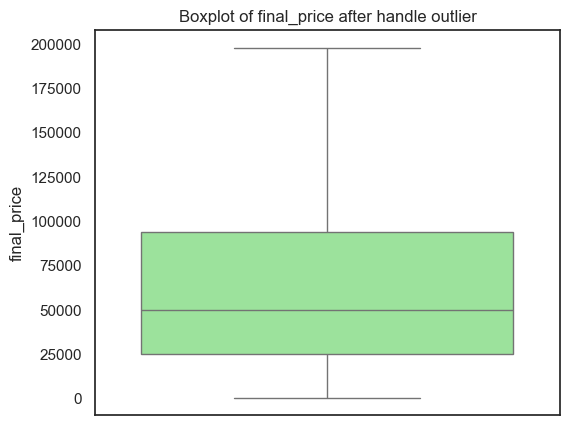

In [69]:
df.columns = df.columns.str.strip()  # કોલમ નામો સાફ કરવા

Q1 = df['final_price'].quantile(0.25)
Q3 = df['final_price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df.copy()
df['final_price'] = np.clip(df['final_price'], lower_bound, upper_bound)

plt.figure(figsize=(6, 5))
sns.boxplot(y=df1['final_price'], color='lightgreen')
plt.title('Boxplot of final_price after handle outlier')
plt.show()

In [70]:
df

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,C109995,29,Female,Pune,Maharashtra,Regular,O149995,2024-06-11,Health,Supplements,49293,1,11,43870.77,Debit Card,Standard,9,No
99996,C109996,28,Male,Mumbai,Maharashtra,Premium,O149996,2024-04-27,Fashion,Men T-Shirt,5722,2,22,8926.32,Cash on Delivery,Express,1,No
99997,C109997,44,Female,Jaipur,Rajasthan,Premium,O149997,2024-04-14,Grocery,Snacks,6311,4,11,22467.16,Cash on Delivery,Express,9,No
99998,C109998,45,Male,Jaipur,Rajasthan,Premium,O149998,2024-09-08,Beauty,Shampoo,46888,1,28,33759.36,Debit Card,Standard,1,No


----------------Bivariate Analysis-------------------

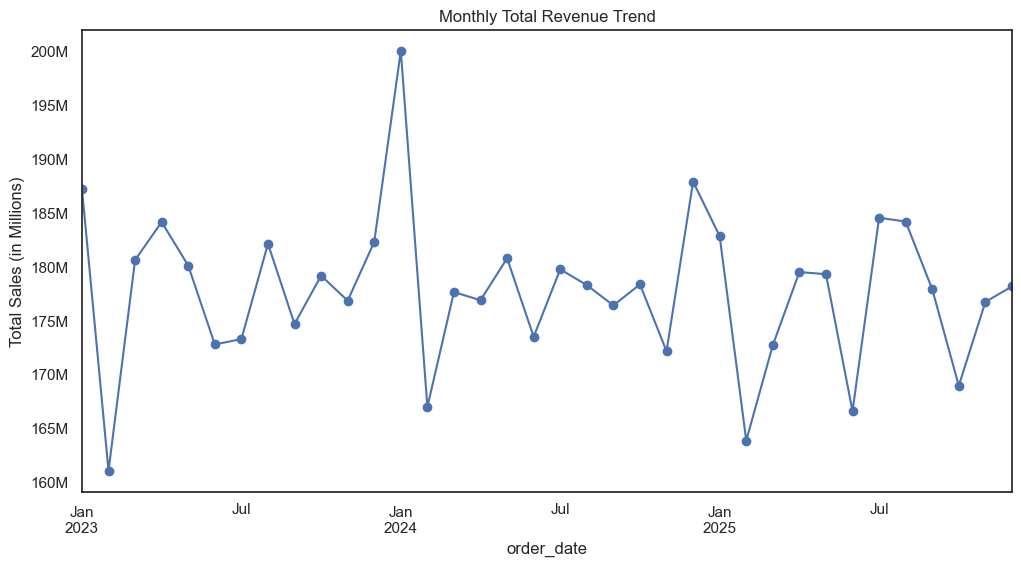

In [71]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

ax = df.set_index('order_date').resample('M')['final_price'].sum().plot(kind='line', marker='o', figsize=(12, 6))

def millions(x, pos):
    return f'{x*1e-6:.0f}M'

formatter = FuncFormatter(millions)
ax.yaxis.set_major_formatter(formatter)

plt.title('Monthly Total Revenue Trend')
plt.ylabel('Total Sales (in Millions)')
#plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Insights:

Above chart shown month wise total sale.

In January 2024, revenue reached its highest level 200M sale. This could potentially be the result of a New Years sale or holiday season impact.

Your monthly revenue consistently stays within a high-performance band of 160M to 200M.

The chart shows significant "zig-zag" fluctuations. Sales are not steady, meaning the business relies heavily on specific events or monthly cycles rather than consistent daily growth.

Your normal monthly sales target should be at least $180M. Anything less means the business is underperforming.

In [72]:
import plotly.express as px
import pandas as pd
import requests
import json

# 1. Load the India States GeoJSON with error handling
repo_url = "https://gist.githubusercontent.com/jbrobst/56c13bbbf9d97d187fea01ca62ea5112/raw/e388c4cae20aa53cb5090210a42ebb9b765c0a36/india_states.geojson"

try:
    # Adding a timeout and basic headers to prevent connection hangs
    response = requests.get(repo_url, timeout=10)
    response.raise_for_status()
    india_states = response.json()
except Exception as e:
    print(f"Failed to load GeoJSON: {e}")
    # Fallback: If you saved the file locally as suggested before:
    # with open('india_states.json') as f:
    #     india_states = json.load(f)

# 2. Aggregate your data
# Ensure 'df' is already defined in your environment before this step!
state_data = df.groupby('state')['final_price'].sum().reset_index()

# 3. Create the Map
fig = px.choropleth(
    state_data,
    geojson=india_states,
    featureidkey='properties.ST_NM', # This is the correct key for this specific GeoJSON
    locations='state',               # Your column 'state' must match 'ST_NM' values exactly
    color='final_price',
    color_continuous_scale='Reds',   # Changed to Reds for better visibility on white backgrounds
    title='Total Sales by State (India)',
)

# 4. Fit the map to India
fig.update_geos(fitbounds="locations", visible=False)

# 5. Improve Layout
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})

fig.show()

Insights:

Above chat shown State wise Total sales, the hover effect shows the State and Final Price.

Maharashtra shows the highest sales (over 1.27 Billion), outperforming all other states significantly. It is your primary revenue generator.

There is a balanced and strong sales performance across South India (Tamil Nadu, Telangana, Karnataka).

Excluding Maharashtra, the next 7 top states are performing within a very tight range of 634M to 648M. This indicates a highly stable and predictable demand for your products across different states.


In [73]:
df_pivot = df.pivot_table(
    values='product_price', 
    index='product_category', 
    aggfunc='mean'
)
df_pivot

,product_price
product_category,
Beauty,30058.165324
Electronics,30452.550314
Fashion,29955.913080
Grocery,30105.133136
Health,30137.817179
Home & Kitchen,30276.319979


Insights:

Above chart shown Product Category wise Product Price.

Electronics has the highest value. Even though it's only a small lead, it shows that your customers are spending the most money on tech and gadgets right now.

The biggest takeaway is how similar all these numbers are. Whether it's Electronics or Fashion, the total values are almost the same. This means your business is stable

Your customers seem to spend a very specific amount of money regardless of what they are buying. This makes it easier for you to predict your monthly budget.

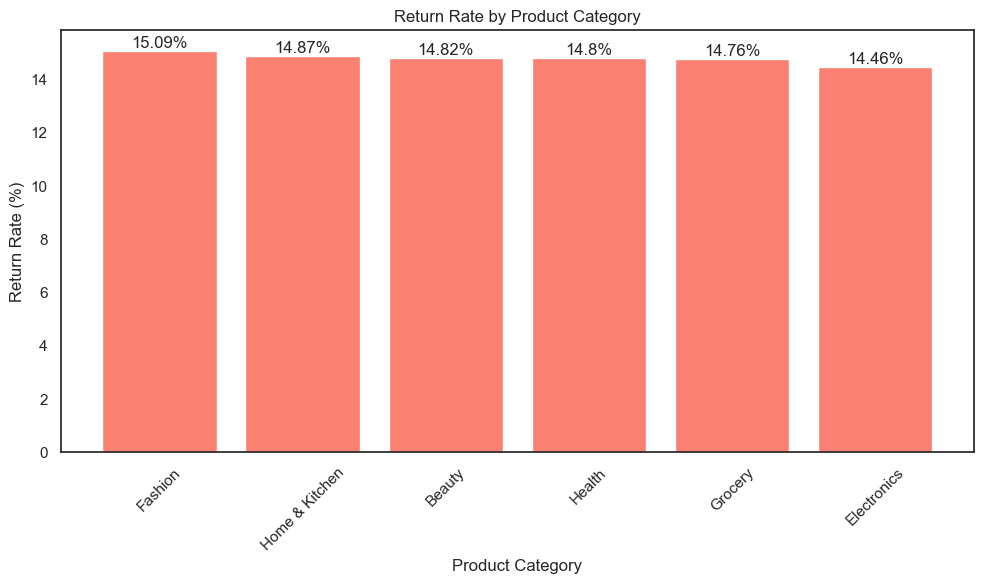

,product_category,No,Yes,Return Rate (%)
2,Fashion,13933,2476,15.089280
5,Home & Kitchen,14143,2470,14.867875
0,Beauty,13866,2412,14.817545
4,Health,14190,2465,14.800360
3,Grocery,13927,2411,14.757008
1,Electronics,13999,2366,14.457684


In [74]:
data = {
    "product_category": ["Beauty", "Electronics", "Fashion", "Grocery", "Health", "Home & Kitchen"],
    "No": [13866, 13999, 13933, 13927, 14190, 14143],
    "Yes": [2412, 2366, 2476, 2411, 2465, 2470]
}

data1 = pd.DataFrame(data)
data1['Total'] = data1['No'] + data1['Yes']
data1['Return Rate (%)'] = (data1['Yes'] / data1['Total']) * 100

data1_sorted = data1.sort_values(by='Return Rate (%)', ascending=False)

# Visualization
plt.figure(figsize=(10, 6))
bars = plt.bar(data1_sorted['product_category'], data1_sorted['Return Rate (%)'], color='salmon')
plt.xlabel('Product Category')
plt.ylabel('Return Rate (%)')
plt.title('Return Rate by Product Category')
plt.xticks(rotation=45)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{round(yval, 2)}%', va='bottom', ha='center')

plt.tight_layout()
plt.show()

data1_stored=(data1_sorted[['product_category', 'No', 'Yes', 'Return Rate (%)']])
data1_stored

Insights:

Above chart shown Return rate(%) by Product Category.

Across all categories, the return rate is very stable, staying between 14.4% and 15.1%.

Fashion has the highest return rate at 15.09%. While this is common in the industry (due to sizing or style issues), it is your "weakest link" regarding returns, To reduce this, consider improving size guides or adding more customer reviews with photos.

Electronics has the lowest return rate at 14.46%. This suggests that customers are generally satisfied with the products they receive and they match their expectations.

--------------------Multivariate Analysis-------------------------

In [75]:
df.head()

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No


In [76]:
df_pivot2 = pd.crosstab(df['product_category'], df['shipping_type'])
df_pivot2 

shipping_type,Express,Standard
product_category,,
Beauty,8296,8217
Electronics,8316,8260
Fashion,8209,8404
Grocery,8255,8337
Health,8483,8375
Home & Kitchen,8449,8399


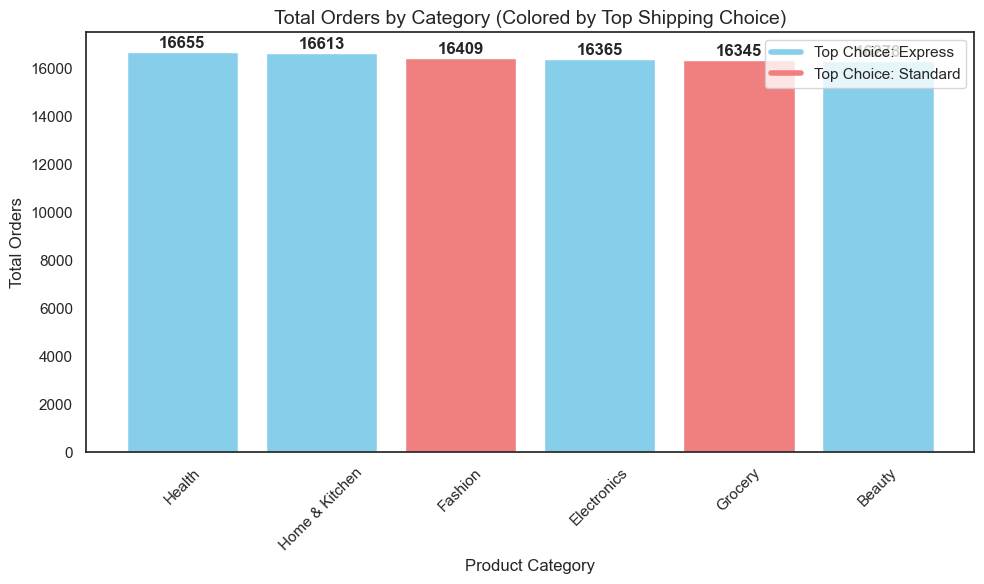

         Category Top Shipping Choice  Total Orders
0          Health    Express (50.38%)         16655
1  Home & Kitchen    Express (50.19%)         16613
4         Fashion   Standard (50.57%)         16409
2     Electronics    Express (50.22%)         16365
5         Grocery   Standard (50.24%)         16345
3          Beauty    Express (50.25%)         16278


In [77]:
from matplotlib.lines import Line2D

data = {
    "Category": ["Health", "Home & Kitchen", "Electronics", "Beauty", "Fashion", "Grocery"],
    "Top Shipping Choice": ["Express (50.38%)", "Express (50.19%)", "Express (50.22%)", "Express (50.25%)", "Standard (50.57%)", "Standard (50.24%)"],
    "Total Orders": [16655, 16613, 16365, 16278, 16409, 16345]
}

shipping = pd.DataFrame(data)

shipping = shipping.sort_values(by="Total Orders", ascending=False)

plt.figure(figsize=(10, 6))

colors = ['skyblue' if 'Express' in choice else 'lightcoral' for choice in shipping['Top Shipping Choice']]

bars = plt.bar(shipping['Category'], shipping['Total Orders'], color=colors)

plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Orders', fontsize=12)
plt.title('Total Orders by Category (Colored by Top Shipping Choice)', fontsize=14)
plt.xticks(rotation=45)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, f'{int(yval)}', 
             ha='center', va='bottom', fontweight='bold')

legend_elements = [
    Line2D([0], [0], color='skyblue', lw=4, label='Top Choice: Express'),
    Line2D([0], [0], color='lightcoral', lw=4, label='Top Choice: Standard')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()
print(shipping)

Insights:

Above chart shown Product Category and orders wise Shiiping Choice.

Your total orders across all categories (ranging from 16,278 to 16,655) are remarkably similar.

Across all categories, the split between Express and Standard is almost 50/50.

In categories like Health (50.38%), Electronics (50.22%), and Beauty (50.25%), customers prefer Express shipping over standard delivery.

Fashion and Grocery shoppers are more comfortable with Standard shipping, you can consolidate these shipments to save on fuel and courier costs without upsetting the customer.

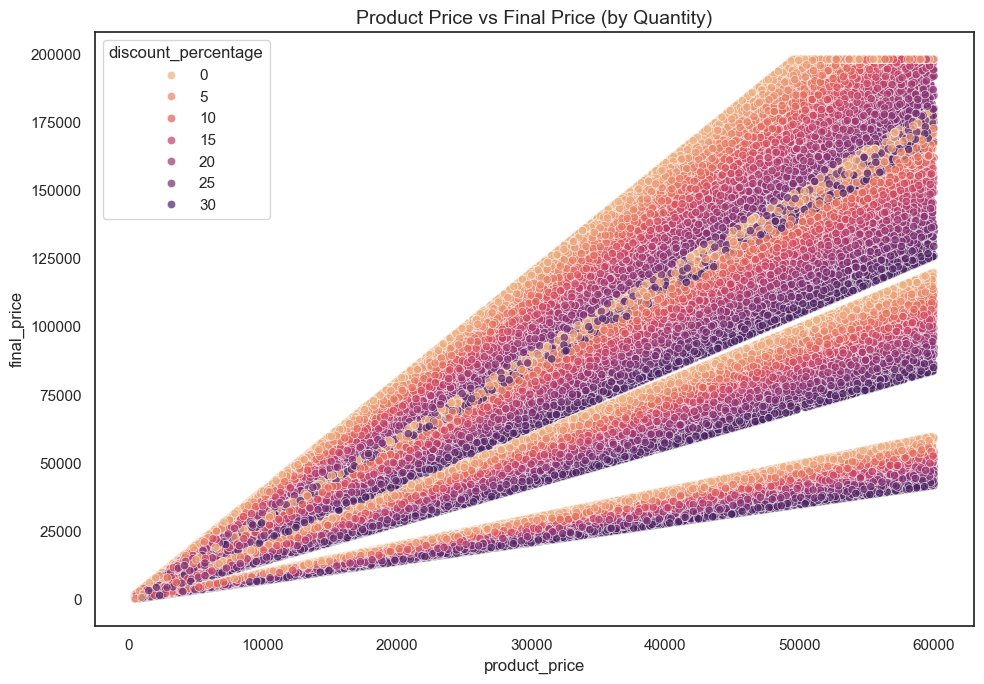

In [78]:
sns.set_theme(style="white")

# 3. Create the scatter plot
plt.figure(figsize=(10, 7))
scatter = sns.scatterplot(
    data=df, 
    x='product_price', 
    y='final_price', 
    hue='discount_percentage', 
    palette='flare',  # This palette matches the pink-to-dark-purple gradient in your image
    alpha=0.7,        # Slight transparency for overlapping points
    edgecolor='w'     # White edge around dots for clarity
)

# 4. Add titles and labels
plt.title('Product Price vs Final Price (by Quantity)', fontsize=14)
plt.xlabel('product_price')
plt.ylabel('final_price')

# 5. Customize the legend
plt.legend(title='discount_percentage', loc='upper left')

# 6. Display the plot
plt.tight_layout()
plt.show()

Insight:

The chart visualizes the relationship between Product Price and Final Price, segmented by Discount Percentage (colors).

There is a high density of data points between the 40,000 and 60,000 product price range. This indicates that your premium products are your high-volume movers.

This data indicates that customers are willing to purchase your products even without any discounts. This reflects a strong brand position and high customer loyalty.

The uppermost section of the graph (the Top Band) shows that even high-priced items are being sold at their full retail price. This suggests that your premium inventory maintains its value well and does not require aggressive discounting to move off the shelves.

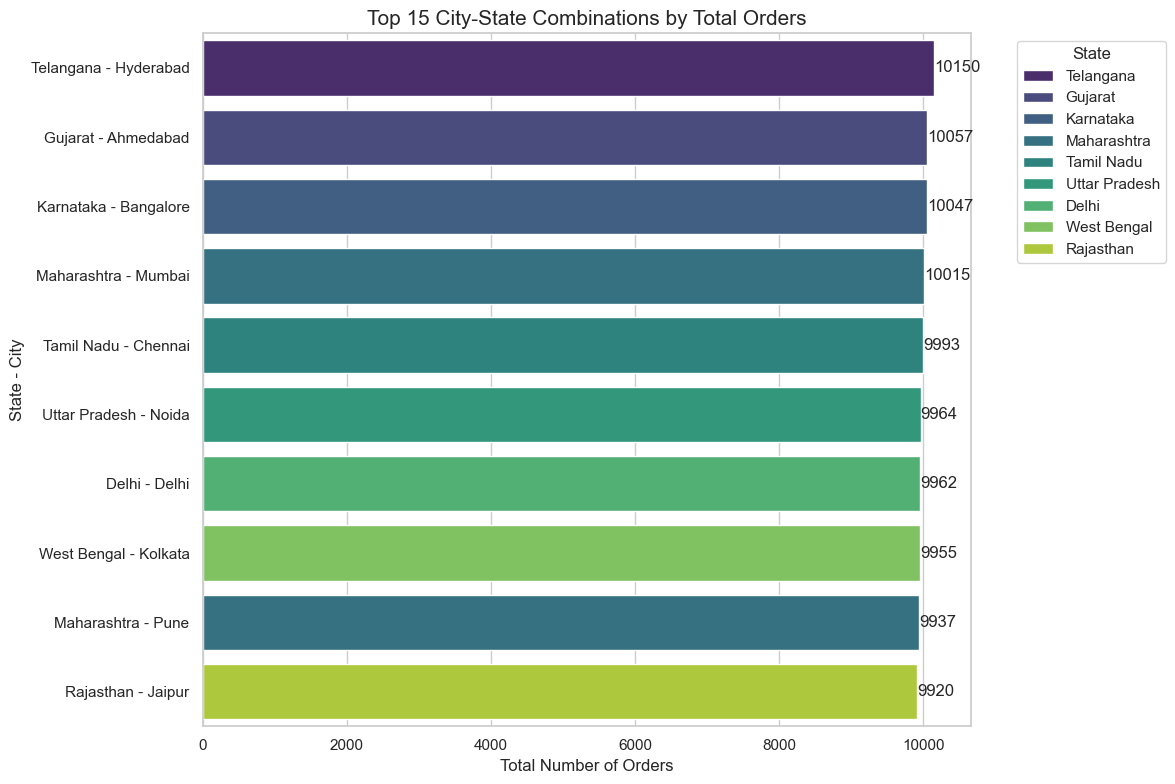

In [79]:
combined_counts = df.groupby(['state', 'city']).size().reset_index(name='total_orders')

# Create a combined label for the chart
combined_counts['state_city'] = combined_counts['state'] + " - " + combined_counts['city']

# Sort by orders
combined_counts = combined_counts.sort_values(by='total_orders', ascending=False)

# Take top 15 for a clean visualization
top_combined = combined_counts.head(15)

# Plotting
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Use hue for state to make it visually distinct
barplot = sns.barplot(
    data=top_combined,
    x='total_orders',
    y='state_city',
    hue='state',
    dodge=False,
    palette='viridis'
)

plt.title('Top 15 City-State Combinations by Total Orders', fontsize=15)
plt.xlabel('Total Number of Orders', fontsize=12)
plt.ylabel('State - City', fontsize=12)
plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add values on bars
for p in barplot.patches:
    width = p.get_width()
    if width > 0: # Avoid errors on empty patches from hue logic
        plt.text(width + 1, p.get_y() + p.get_height()/2, f'{int(width)}', va='center')

plt.tight_layout()
plt.show()

Insights:

Above chart shown Top 15 State and City wise Total Orders.

Hyderabad (Telangana) is the top-performing city, leading with 10,150 total orders.

The gap between the top city (Hyderabad) and the 10th city (Jaipur) is very small (less than 250 orders). This shows that demand is very well-distributed across all major Indian metros.

Hyderabad, Ahmedabad, Bangalore, and Mumbai are the only cities that crossed the 10,000 orders milestone.

In [80]:
df.columns

Index(['customer_id', 'age', 'gender', 'city', 'state', 'customer_segment',
       'order_id', 'order_date', 'product_category', 'product_subcategory',
       'product_price', 'quantity', 'discount_percentage', 'final_price',
       'payment_method', 'shipping_type', 'delivery_days', 'return_status'],
      dtype='object')

--------------------------------------------Conclusions-------------------------------------

Based on the Retail Exploratory Data Analysis notebook, here are the key conclusions and business insights derived from the analysis of the 100,000-row e-commerce dataset.

The dataset is highly clean, with zero missing values and zero duplicate entries across all 100,000 records.

Most of the sales come from products priced between 40,000 and 60,000. This shows that your expensive, high-quality products are the ones that sell the most.

The data shows that many people buy products even when there is no discount (0% off). This means customers trust the brand and are happy to pay the full price.

The most expensive items in the store sell well without needing big price cuts. This suggests these products are highly wanted and keep their value.

Customers are divided into three groups: New, Regular, and Premium. This helps the business create special offers for each type of shopper.

Customers use different ways to pay, such as Debit Cards, Credit Cards, UPI (online apps), and Cash on Delivery.

On average, a customer spends about ₹64,165 per order. The products are priced between ₹500 and ₹60,000.